# Neural Collaborative Filtering (NCF)

# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Concatenate,
    Dropout
)

from tensorflow.keras.optimizers import Adam

# LOAD CLEANED DATASET

In [2]:
df = pd.read_csv('cleaned_sample_data.csv')
df.head()

,user_id,product_id,rating,timestamp
0,A1PSUH0U1FPQ6R,B002QXZPFE,4.0,2013-08-19
1,A23QSTB241NRF3,B0040HJOO2,1.0,2012-04-24
2,A1IU4JZFDZA9HJ,B004LRO7FW,5.0,2012-01-12
3,A1B2D4J8KF4DFN,B006DKEQL0,2.0,2013-05-10
4,A2SYLJAZO4SPA0,B00006G33N,4.0,2006-08-22


# INFORMASI DATASET

In [3]:
print("Ukuran dataset:")
print(df.shape)

print(f"Jumlah user unik: {df['user_id'].nunique()}")
print(f"Jumlah produk unik: {df['product_id'].nunique()}")

Ukuran dataset:
(155938, 4)
Jumlah user unik: 13345
Jumlah produk unik: 27447


# ENCODE USER DAN PRODUK

In [4]:
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

df['user_encoded'] = user_encoder.fit_transform(df['user_id'])
df['product_encoded'] = product_encoder.fit_transform(df['product_id'])

df.head()

,user_id,product_id,rating,timestamp,user_encoded,product_encoded
0,A1PSUH0U1FPQ6R,B002QXZPFE,4.0,2013-08-19,2540,11420
1,A23QSTB241NRF3,B0040HJOO2,1.0,2012-04-24,3924,14674
2,A1IU4JZFDZA9HJ,B004LRO7FW,5.0,2012-01-12,1859,16452
3,A1B2D4J8KF4DFN,B006DKEQL0,2.0,2013-05-10,1074,20062
4,A2SYLJAZO4SPA0,B00006G33N,4.0,2006-08-22,6395,819


# MENENTUKAN JUMLAH USER DAN PRODUK

In [5]:
num_users = df['user_encoded'].nunique()
num_products = df['product_encoded'].nunique()

print(f"Jumlah user: {num_users}")
print(f"Jumlah produk: {num_products}")

Jumlah user: 13345
Jumlah produk: 27447


# MENENTUKAN FITUR DAN TARGET

In [6]:
X = df[['user_encoded', 'product_encoded']]
y = df['rating'].astype(np.float32)

# SPLIT TRAINING DAN TESTING

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Jumlah data train: {len(X_train)}")
print(f"Jumlah data test: {len(X_test)}")

Jumlah data train: 124750
Jumlah data test: 31188


# MEMBUAT INPUT LAYER

In [8]:
user_input = Input(shape=(1,), name='user_input')
product_input = Input(shape=(1,), name='product_input')

# MEMBUAT EMBEDDING LAYER

In [9]:
user_embedding = Embedding(
    input_dim=num_users,
    output_dim=64,
    name='user_embedding'
)(user_input)

product_embedding = Embedding(
    input_dim=num_products,
    output_dim=64,
    name='product_embedding'
)(product_input)

# FLATTEN EMBEDDING

In [10]:
user_vector = Flatten()(user_embedding)
product_vector = Flatten()(product_embedding)

# MENGGABUNGKAN EMBEDDING

In [11]:
concat = Concatenate()([
    user_vector,
    product_vector
])

# MEMBUAT DENSE LAYER

In [12]:
dense = Dense(
    64,
    activation='relu'
)(concat)

dropout = Dropout(0.3)(dense)

dense = Dense(
    32,
    activation='relu'
)(dropout)

dropout = Dropout(0.3)(dense)

# OUTPUT LAYER

In [13]:
output = Dense(
    1,
    activation='linear'
)(dropout)

# MEMBUAT MODEL

In [14]:
model = Model(
    inputs=[user_input, product_input],
    outputs=output
)

# MENAMPILKAN ARSITEKTUR MODEL

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 64)     │    854,080 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_embedding   │ (None, 1, 64)     │  1,756,608 │ product_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 64)        │          0 │ product_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,621,057 (10.00 MB)

 Trainable params: 2,621,057 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILE MODEL

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# EARLY STOPPING

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# TRAINING MODEL

In [19]:
history = model.fit(
    x=[
        X_train['user_encoded'],
        X_train['product_encoded']
    ],

    y=y_train,

    validation_data=(
        [
            X_test['user_encoded'],
            X_test['product_encoded']
        ],
        y_test
    ),

    epochs=10,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - loss: 3.4038 - mae: 1.3869 - val_loss: 1.1152 - val_mae: 0.8112
Epoch 2/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - loss: 1.4377 - mae: 0.9433 - val_loss: 1.1213 - val_mae: 0.8076
Epoch 3/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 1.2954 - mae: 0.8938 - val_loss: 1.1591 - val_mae: 0.8209


# EVALUASI MODEL

In [20]:
loss, mae = model.evaluate(
    [
        X_test['user_encoded'],
        X_test['product_encoded']
    ],
    y_test
)

print(f"Loss: {loss:.4f}")
print(f"MAE: {mae:.4f}")

975/975 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.1152 - mae: 0.8112
Loss: 1.1152
MAE: 0.8112


# VISUALISASI LOSS

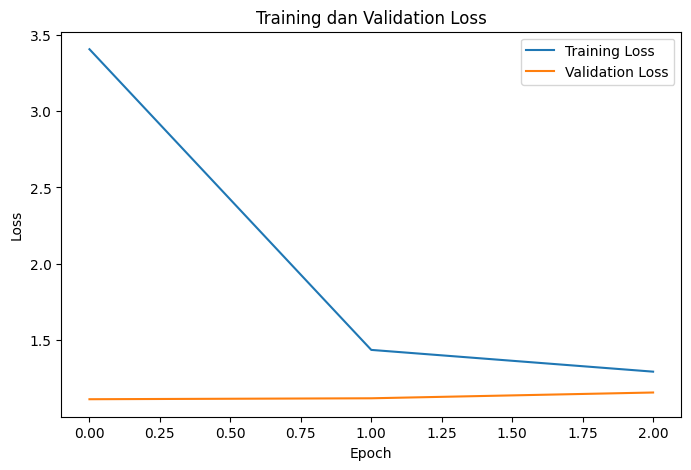

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

# VISUALISASI MAE

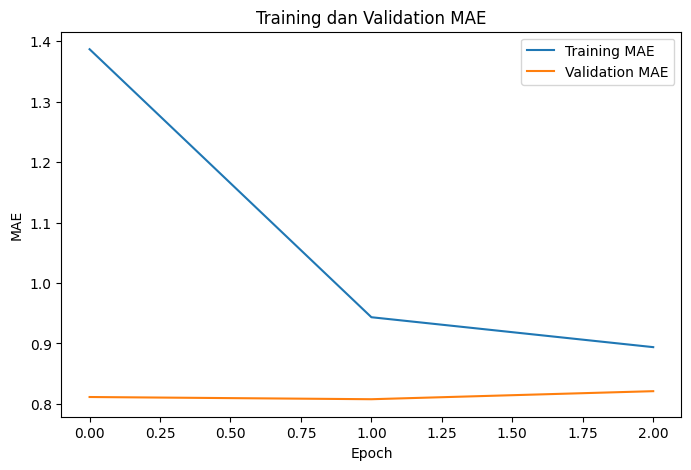

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['mae'],
    label='Training MAE'
)

plt.plot(
    history.history['val_mae'],
    label='Validation MAE'
)

plt.title('Training dan Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.legend()

plt.show()


# MENYIMPAN MODEL

In [23]:
model.save('ncf_model.keras')

# CONTOH PREDIKSI

In [24]:
sample_user = X_test.iloc[0]['user_encoded']

sample_product = X_test.iloc[0]['product_encoded']

predicted_rating = model.predict([
    np.array([sample_user]),
    np.array([sample_product])
])

print(f"Prediksi rating: {predicted_rating[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Prediksi rating: 4.01


# KESIMPULAN MODELING:

1. Model Neural Collaborative Filtering berhasil dibuat.
2. User dan produk direpresentasikan menggunakan embedding.
3. Model berhasil mempelajari pola interaksi user dan produk.
4. Early stopping digunakan untuk mengurangi overfitting.
5. Model dievaluasi menggunakan loss dan MAE.
- MAE: 0.81
- Loss: 1.11
6. Model berhasil mempelajari pola interaksi user dan produk
dengan overfitting yang lebih terkendali menggunakan
dropout dan early stopping.
7. Model siap digunakan untuk tahap recommendation system.